In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, balanced_accuracy_score
from sklearn.decomposition import PCA

### Data Loading & Preprocessing

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ML_2026_K2_BreastCancer/data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.describe()


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [ ]:
print(df.isnull().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [ ]:
print(df.isna().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [ ]:
print(df.duplicated().sum())

0


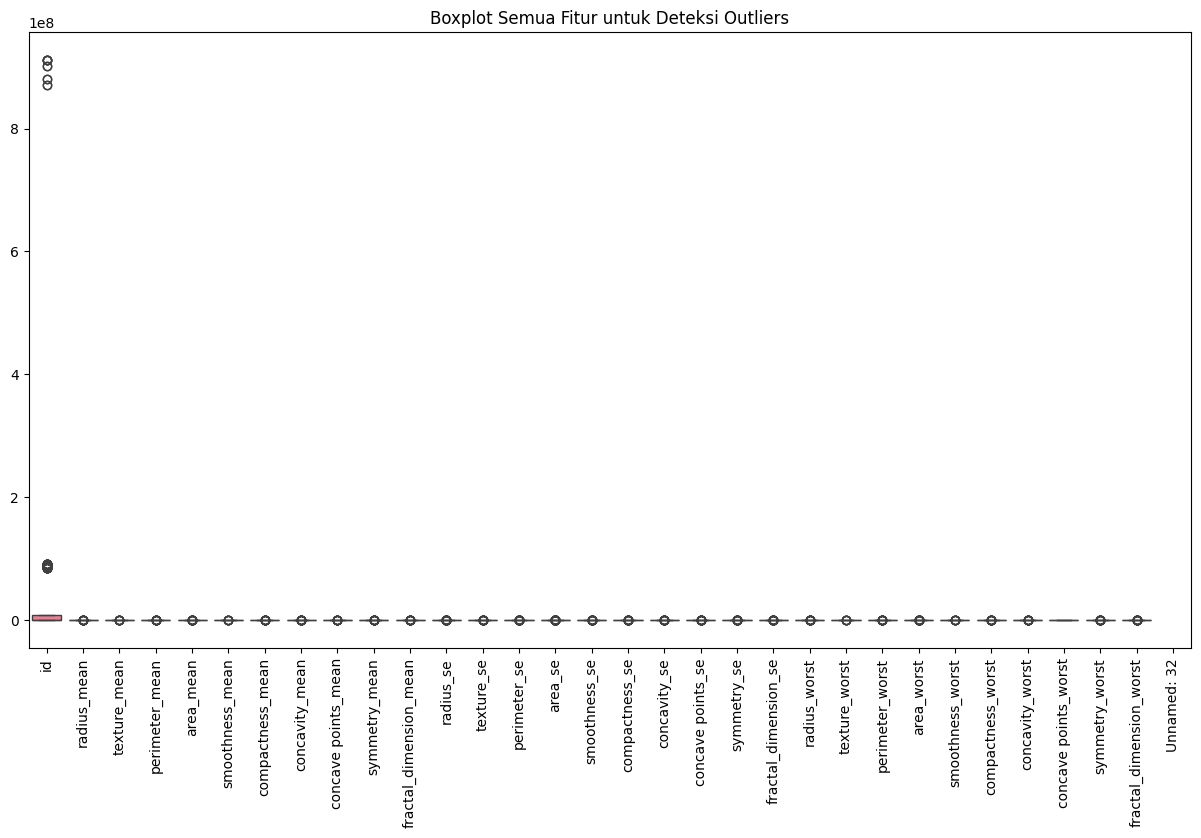

In [ ]:
# Pilih hanya kolom numerik
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

# Boxplot untuk semua fitur numerik
plt.figure(figsize=(15,8))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=90)   # putar label agar tidak bertumpuk
plt.title("Boxplot Semua Fitur untuk Deteksi Outliers")
plt.show()

In [ ]:
df = df.drop(columns=['id','Unnamed: 32'], errors='ignore')

In [ ]:
X = df.drop('diagnosis', axis=1)   # diagnosis = target
y = df['diagnosis']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled_df.head())

   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0     1.097064     -2.073335        1.269934   0.984375         1.568466   
1     1.829821     -0.353632        1.685955   1.908708        -0.826962   
2     1.579888      0.456187        1.566503   1.558884         0.942210   
3    -0.768909      0.253732       -0.592687  -0.764464         3.283553   
4     1.750297     -1.151816        1.776573   1.826229         0.280372   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0          3.283515        2.652874             2.532475       2.217515   
1         -0.487072       -0.023846             0.548144       0.001392   
2          1.052926        1.363478             2.037231       0.939685   
3          3.402909        1.915897             1.451707       2.867383   
4          0.539340        1.371011             1.428493      -0.009560   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0           

In [ ]:
X_scaled_df

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.110995,0.721473,2.060786,2.343856,1.041842,0.219060,1.947285,2.320965,-0.312589,-0.931027,...,1.901185,0.117700,1.752563,2.015301,0.378365,-0.273318,0.664512,1.629151,-1.360158,-0.709091
565,1.704854,2.085134,1.615931,1.723842,0.102458,-0.017833,0.693043,1.263669,-0.217664,-1.058611,...,1.536720,2.047399,1.421940,1.494959,-0.691230,-0.394820,0.236573,0.733827,-0.531855,-0.973978
566,0.702284,2.045574,0.672676,0.577953,-0.840484,-0.038680,0.046588,0.105777,-0.809117,-0.895587,...,0.561361,1.374854,0.579001,0.427906,-0.809587,0.350735,0.326767,0.414069,-1.104549,-0.318409
567,1.838341,2.336457,1.982524,1.735218,1.525767,3.272144,3.296944,2.658866,2.137194,1.043695,...,1.961239,2.237926,2.303601,1.653171,1.430427,3.904848,3.197605,2.289985,1.919083,2.219635


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

### Data Exploration & Visualization

In [ ]:
print(X_scaled_df.describe())

        radius_mean  texture_mean  perimeter_mean     area_mean  \
count  5.690000e+02  5.690000e+02    5.690000e+02  5.690000e+02   
mean  -1.373633e-16  6.868164e-17   -1.248757e-16 -2.185325e-16   
std    1.000880e+00  1.000880e+00    1.000880e+00  1.000880e+00   
min   -2.029648e+00 -2.229249e+00   -1.984504e+00 -1.454443e+00   
25%   -6.893853e-01 -7.259631e-01   -6.919555e-01 -6.671955e-01   
50%   -2.150816e-01 -1.046362e-01   -2.359800e-01 -2.951869e-01   
75%    4.693926e-01  5.841756e-01    4.996769e-01  3.635073e-01   
max    3.971288e+00  4.651889e+00    3.976130e+00  5.250529e+00   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count     5.690000e+02      5.690000e+02    5.690000e+02         5.690000e+02   
mean     -8.366672e-16      1.873136e-16    4.995028e-17        -4.995028e-17   
std       1.000880e+00      1.000880e+00    1.000880e+00         1.000880e+00   
min      -3.112085e+00     -1.610136e+00   -1.114873e+00        -1.26182

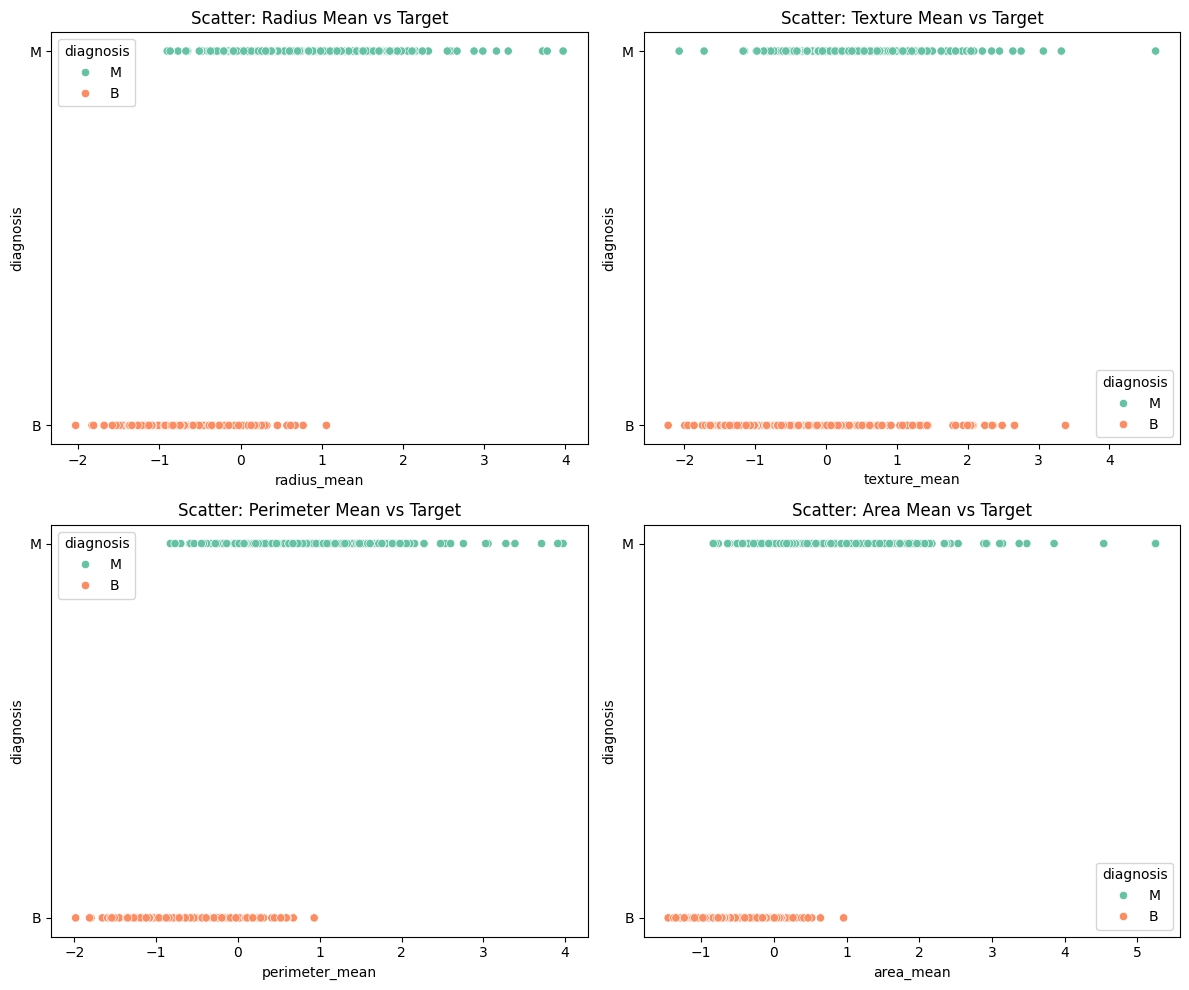

In [ ]:
plt.figure(figsize=(12,10))

# Scatter 1: radius_mean
plt.subplot(2,2,1)
sns.scatterplot(x=X_scaled_df['radius_mean'], y=y, hue=y, palette='Set2')
plt.title("Scatter: Radius Mean vs Target")

# Scatter 2: texture_mean
plt.subplot(2,2,2)
sns.scatterplot(x=X_scaled_df['texture_mean'], y=y, hue=y, palette='Set2')
plt.title("Scatter: Texture Mean vs Target")

# Scatter 3: perimeter_mean
plt.subplot(2,2,3)
sns.scatterplot(x=X_scaled_df['perimeter_mean'], y=y, hue=y, palette='Set2')
plt.title("Scatter: Perimeter Mean vs Target")

# Scatter 4: area_mean
plt.subplot(2,2,4)
sns.scatterplot(x=X_scaled_df['area_mean'], y=y, hue=y, palette='Set2')
plt.title("Scatter: Area Mean vs Target")

plt.tight_layout()
plt.show()


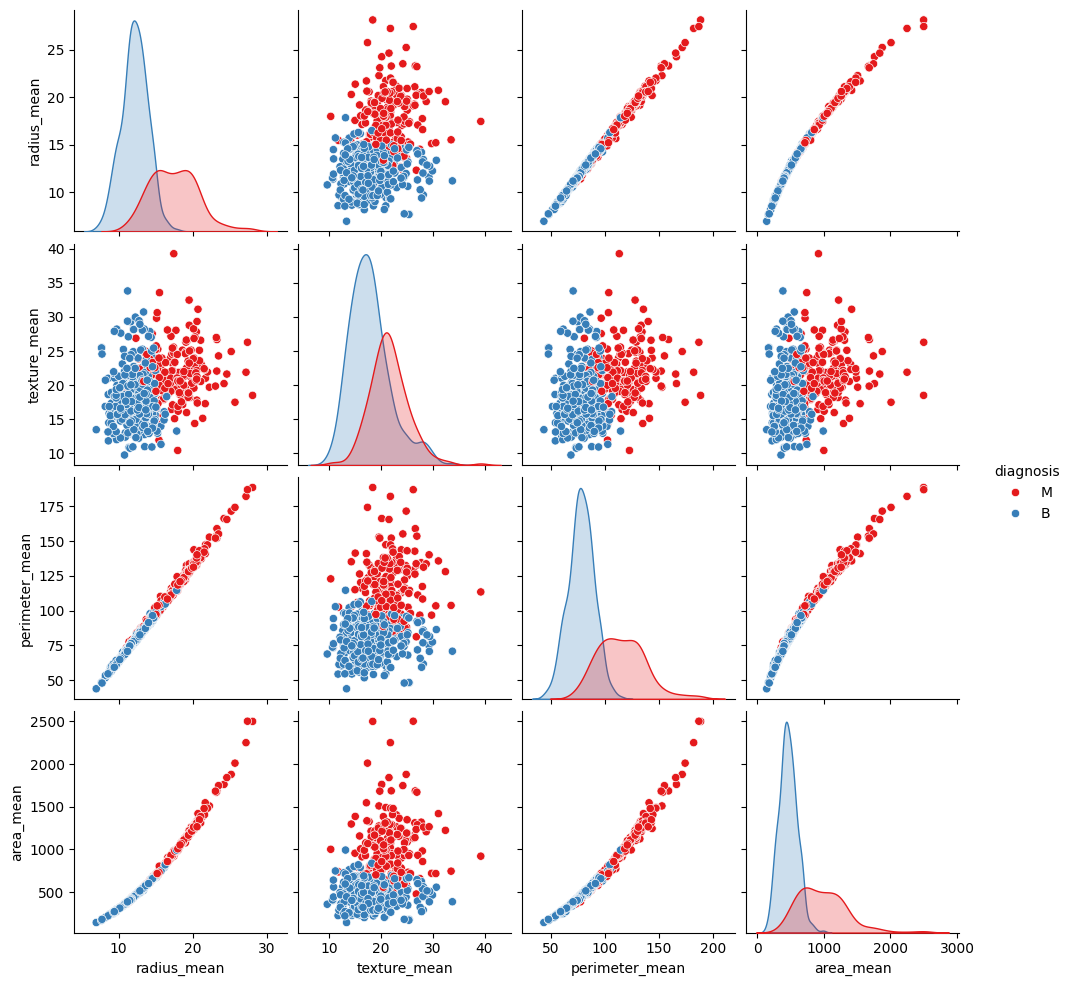

In [ ]:
selected_features = ["radius_mean", "texture_mean", "perimeter_mean", "area_mean"]

# Buat pairplot
sns.pairplot(data=df[selected_features + ["diagnosis"]],
             hue="diagnosis",      # warna berdasarkan label
             diag_kind="kde",      # distribusi di diagonal
             palette="Set1")

plt.show()


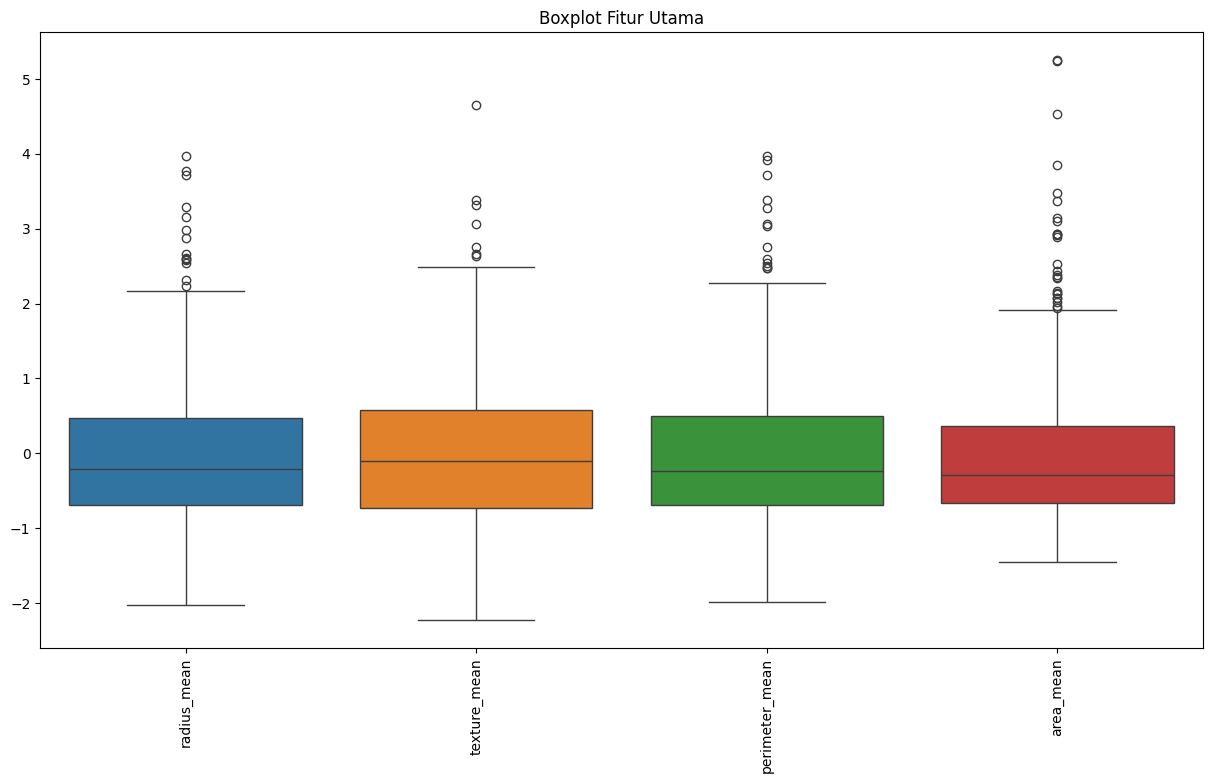

In [ ]:
plt.figure(figsize=(15,8))
sns.boxplot(data=X_scaled_df[['radius_mean','texture_mean','perimeter_mean','area_mean']])
plt.xticks(rotation=90)
plt.title("Boxplot Fitur Utama")
plt.show()

/tmp/ipykernel_3771/962961921.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='Set2')


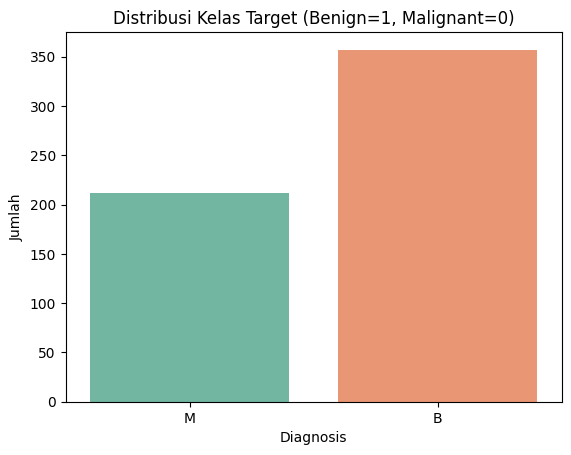

In [ ]:
sns.countplot(x=y, palette='Set2')
plt.title("Distribusi Kelas Target (Benign=1, Malignant=0)")
plt.xlabel("Diagnosis")
plt.ylabel("Jumlah")
plt.show()

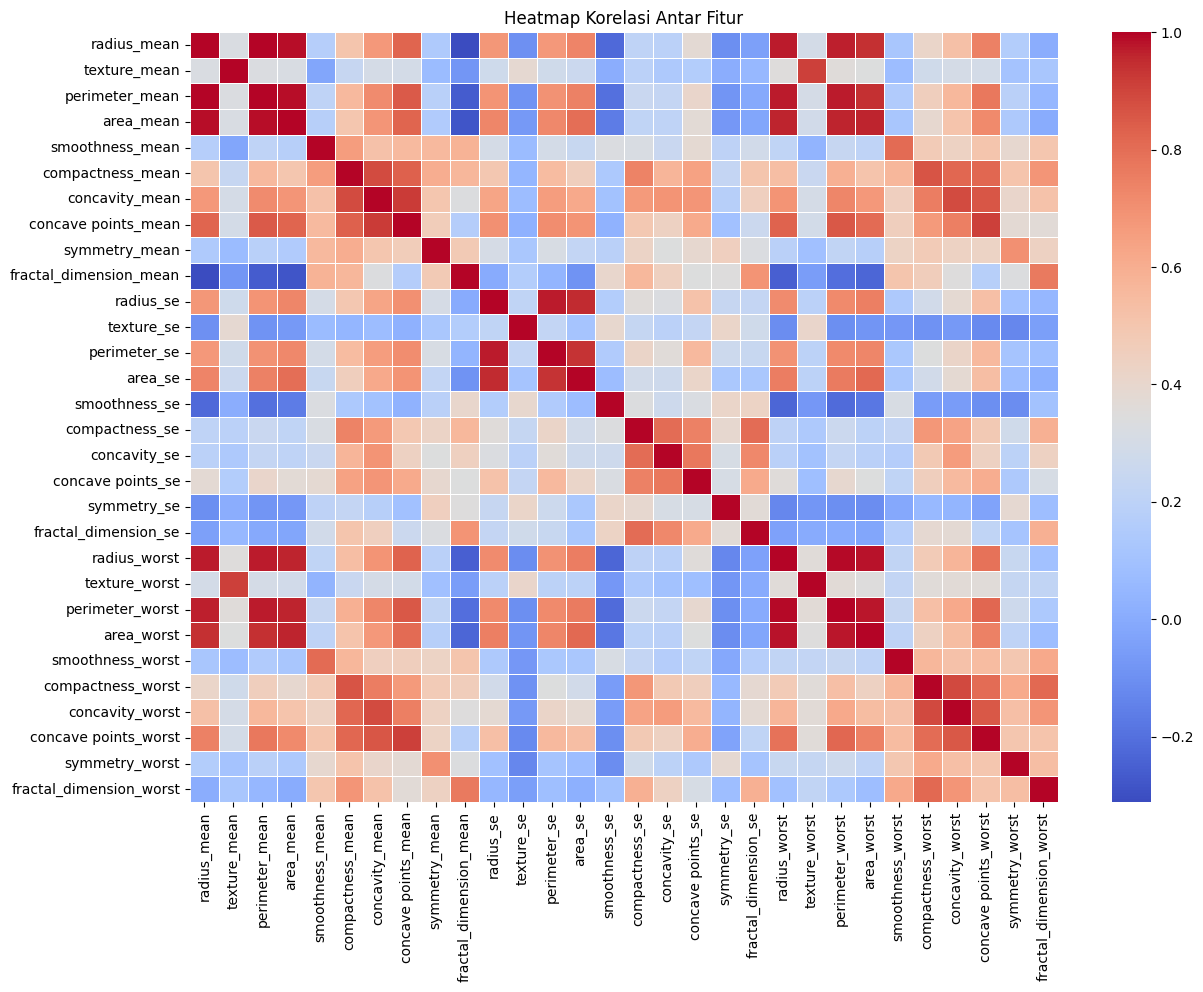

In [ ]:
# Hitung matriks korelasi
corr_matrix = X_scaled_df.corr()

# Plot heatmap
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()

### Data Splitting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (455, 30)
Test shape: (114, 30)


###  Logistic Regression Model Training

In [ ]:
model = LogisticRegression(max_iter=1000)

In [ ]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
print("Intercept:", model.intercept_)
print("Jumlah koefisien:", len(model.coef_[0]))

Intercept: [-0.44114097]
Jumlah koefisien: 30


### Model Evaluation

In [ ]:
y_train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

In [ ]:
y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

In [ ]:
print("Akurasi pada data training:", train_accuracy)
print("Akurasi pada data testing:", test_accuracy)

Akurasi pada data training: 0.9868131868131869
Akurasi pada data testing: 0.9649122807017544


### Prediction

In [ ]:
X_test_array = X_test.to_numpy()

In [ ]:
data = X_test_array[10].reshape(1, -1)
print("Prediksi:", model.predict(data))

Prediksi: ['M']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


### Eksperimen Baseline

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(name, balanced_accuracy_score(y_test, y_pred))

Logistic Regression 0.9573412698412699
KNN 0.9454365079365079
Random Forest 0.9642857142857143


### Integrasi Metode Paper

In [ ]:
# PCA reduksi ke 2 dimensi
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [ ]:
# Latih Logistic Regression di ruang PCA
logreg = LogisticRegression()
logreg.fit(X_train_pca, y_train)

LogisticRegression()

In [ ]:
# Evaluasi
y_pred_pca = logreg.predict(X_test_pca)
print("Logistic Regression + PCA Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_pred_pca))

Logistic Regression + PCA Balanced Accuracy: 0.9216269841269842


### Optimasi & Hyperparameter Tuning (RandomizedSearchCV)

##### Logistic Regression

In [ ]:
param_logreg = {
    "C": np.logspace(-3, 3, 10),
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"]
}

logreg = LogisticRegression(max_iter=1000)
search_logreg = RandomizedSearchCV(
    logreg, param_logreg,
    n_iter=10, cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1, random_state=42
)

search_logreg.fit(X_train, y_train)
y_pred_logreg = search_logreg.predict(X_test)

print("Logistic Regression Best Params:", search_logreg.best_params_)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_logreg))


Logistic Regression Best Params: {'solver': 'saga', 'penalty': 'l2', 'C': np.float64(10.0)}
Balanced Accuracy: 0.9692460317460317


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
search_logreg = RandomizedSearchCV(
    logreg, param_logreg,
    n_iter=10, cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1, random_state=42
)

search_logreg.fit(X_train, y_train)
y_pred_lr = search_logreg.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


--- Evaluasi Model: LogisticRegression ---
Balanced Accuracy: 0.9692

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.97      0.99      0.98        72
      Benign       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



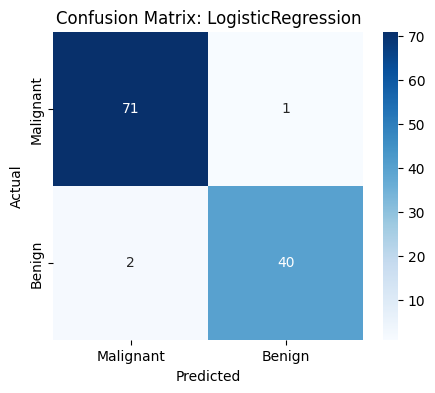

In [ ]:
evaluate_model('LogisticRegression', y_test, y_pred_lr)

##### KNN

In [ ]:
param_knn = {
    "n_neighbors": range(3, 30),
    "weights": ["uniform", "distance"],
    "p": [1, 2],
    "leaf_size": [20, 30, 40],
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"]
}

knn = KNeighborsClassifier()
search_knn = RandomizedSearchCV(
    knn, param_knn,
    n_iter=10, cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1, random_state=42
)

search_knn.fit(X_train, y_train)
y_pred_knn = search_knn.predict(X_test)

print("KNN Best Params:", search_knn.best_params_)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_knn))

KNN Best Params: {'weights': 'distance', 'p': 1, 'n_neighbors': 6, 'leaf_size': 30, 'algorithm': 'auto'}
Balanced Accuracy: 0.9454365079365079


In [ ]:
#Tuning biasa
search_knn = KNeighborsClassifier(
  n_neighbors=5,
  weights='distance',
  metric='euclidean'
)

search_knn.fit(X_train, y_train)
y_pred_knn = search_knn.predict(X_test)

--- Evaluasi Model: kNN ---
Balanced Accuracy: 0.9454

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.95      0.99      0.97        72
      Benign       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



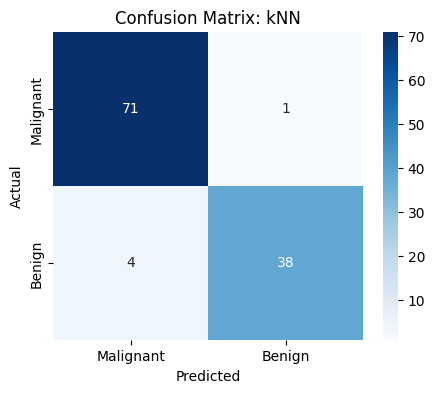

In [ ]:
evaluate_model('kNN', y_test, y_pred_knn)

##### Random Forest

In [ ]:
param_rf = {
  'bootstrap': [True, False],
  'max_depth': [10, 30, 50, None],
  'max_features': ['sqrt', 'log2'],
  'min_samples_leaf': [1, 2, 4],
  'min_samples_split': [2, 5, 10],
  'n_estimators': [200, 500, 1000]
}


rf = RandomForestClassifier(n_jobs=-1, random_state=42)
search_rf = RandomizedSearchCV(
  rf,
  param_distributions=param_rf,
  n_iter=50,
  cv=3,
  verbose=2,
  random_state=42,
  n_jobs=-1
)

search_rf.fit(X_train, y_train)
y_pred_rf = search_rf.predict(X_test)

print("Random Forest Best Params:", search_rf.best_params_)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_rf))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Random Forest Best Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'bootstrap': False}
Balanced Accuracy: 0.9523809523809523


In [ ]:
#Tuning Biasa
search_rf = RandomForestClassifier(
  n_estimators=200,
  bootstrap=True,
  max_features="sqrt",
  max_depth=10,
  max_leaf_nodes=6,
  min_samples_split=2,
  random_state=42,
  n_jobs=-1

)
search_rf.fit(X_train, y_train)
y_pred_rf = search_rf.predict(X_test)

--- Evaluasi Model: RandomForest ---
Balanced Accuracy: 0.9405

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.94      1.00      0.97        72
      Benign       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



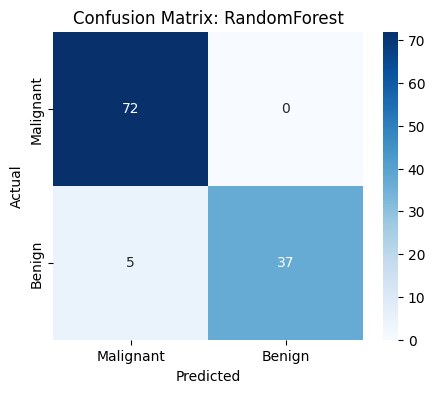

In [ ]:
evaluate_model('RandomForest', y_test, y_pred_rf)

### Komparasi Performa (Sementara)

In [ ]:
models = {
    "Logistic Regression": search_logreg,
    "kNN": search_knn,
    "Random Forest": search_rf
}

In [ ]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Algoritma": name,
        "Balanced Accuracy": round(balanced_accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, pos_label='M'), 4),
        "Recall": round(recall_score(y_test, y_pred, pos_label='M'), 4),
        "F1-Score": round(f1_score(y_test, y_pred, pos_label='M'), 4),
        "AUC-ROC": round(roc_auc_score(y_test, y_prob), 4)
    })


In [ ]:
df_comparison = pd.DataFrame(results)

df_comparison.set_index('Algoritma', inplace=True)

display(df_comparison)

,Balanced Accuracy,Precision,Recall,F1-Score,AUC-ROC
Algoritma,,,,,
Logistic Regression,0.9692,0.9756,0.9524,0.9639,0.9888
kNN,0.9454,0.9744,0.9048,0.9383,0.9823
Random Forest,0.9405,1.0000,0.8810,0.9367,0.9924
